# 1. Data Collection & Preprocessing

## Data Count

In [1]:
# Count the number of rows in the txt file
file_path = "/kaggle/input/manglishdataset/Manglish.txt"

# Open the file and count the lines
with open(file_path, "r", encoding="utf-8") as file:
    line_count = sum(1 for line in file)

line_count

3006

## Data Loading & Conversion

In [2]:
import pandas as pd

# Load the dataset
file_path = "/kaggle/input/manglishdataset/Manglish.txt"
with open(file_path, "r", encoding="utf-8") as file:
    lines = file.readlines()

# Split data and remove quotes
data = []
for line in lines[1:]:  # Skip the header
    parts = line.strip().split(", ", 1)
    if len(parts) == 2:
        # Remove surrounding quotes using .strip('"')
        input_text = parts[0].strip('"')
        target_text = parts[1].strip('"')
        data.append({"input_text": input_text, "target_text": target_text})
    else:
        print(f"Skipping invalid line: {line}")

# Convert to DataFrame
df = pd.DataFrame(data)
print(f"Total rows processed: {len(df)}")

# Save as CSV (optional)
df.to_csv("manglish.csv", index=False, encoding="utf-8")


Skipping invalid line: "Kau dah buat assignment yang due minggu depan ke?","Have you completed the assignment due next week?"

Skipping invalid line: "Kita kena start plan untuk family trip sebelum hujung tahun ni.","We need to start planning for the family trip before the end of this year."

Skipping invalid line: "Kenapa kau tak angkat call aku tadi? Saya call banyak kali tau!","Why didn't you answer my call just now? I called so many times!"

Skipping invalid line: "Saya tengah belajar buat design poster guna Canva.","I'm currently learning to design posters using Canva."

Skipping invalid line: "Saya plan nak start workout routine lepas exam nanti.","I plan to start a workout routine after the exams."

Skipping invalid line: "Saya rasa kita perlu buat group study untuk kelas calculus tu.","I think we need to do a group study for that calculus class."

Skipping invalid line: "Kau tahu tak ada cafe baru buka dekat area kita?","Do you know a new cafe just opened near our area?"

Skipp

## Dataframe Count

In [3]:
len(df)

2718

## Column Names Verification

In [4]:
# Ensure columns are named correctly
assert 'input_text' in df.columns and 'target_text' in df.columns, "Columns should be named 'input_text' and 'target_text'!"

## Dropping Duplicates

In [5]:
# Remove exact duplicates
df = df.drop_duplicates()
print(len(df))

2668


## Dropping Empty Rows

In [6]:
# Drop rows where either column is empty
df = df.dropna()
print(len(df))
print(df.head())

2668
                             input_text                         target_text
0          Saya pergi makan lunch tadi.       I went to have lunch earlier.
1                 Kau buat homework ke?           Did you do your homework?
2        Dia cakap dia busy weekend ni.    He said he is busy this weekend.
3             Jom pergi lepak malam ni?          Let's go hang out tonight?
4  Dia tengah buat revision untuk exam.  He is doing revision for the exam.


## Removing Extra Spaces

In [7]:
# Remove extra spaces
df['input_text'] = df['input_text'].str.strip().str.replace(r'\s+', ' ', regex=True)
df['target_text'] = df['target_text'].str.strip().str.replace(r'\s+', ' ', regex=True)


## Verifying Dataset

In [8]:
# Show dataset structure
print("Dataset info:")
df.info()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
Index: 2668 entries, 0 to 2717
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   input_text   2668 non-null   object
 1   target_text  2668 non-null   object
dtypes: object(2)
memory usage: 62.5+ KB


In [9]:
df.head()

,input_text,target_text
0,Saya pergi makan lunch tadi.,I went to have lunch earlier.
1,Kau buat homework ke?,Did you do your homework?
2,Dia cakap dia busy weekend ni.,He said he is busy this weekend.
3,Jom pergi lepak malam ni?,Let's go hang out tonight?
4,Dia tengah buat revision untuk exam.,He is doing revision for the exam.


## Language Detection

In [10]:
pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 12.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993221 sha256=b255385d7c7dddc9412198a7eee999f8a091b490ab9e8d4a72c14161f10f12e2
  Stored in directory: /root/.cache/pip/wheels/95/03/7d/59ea870c70ce4e5a370638b5462a7711ab78fba2f655d05106
Successfully built langdetect
Note: you may need to restart the kernel to use updated packages.


In [11]:
from langdetect import detect

# Validate only the target_text for proper English translations
def validate_english(text):
    try:
        return detect(text) == 'en'  # Check if the target is in English
    except:
        return False

# Apply language validation ONLY to target_text
df = df[df['target_text'].apply(validate_english)]


## Dropping Empty Rows (After Language Detection)

In [12]:
# Drop rows where either column is empty
df = df.dropna()
print(len(df))
print(df.head())

2457
                             input_text  \
0          Saya pergi makan lunch tadi.   
3             Jom pergi lepak malam ni?   
4  Dia tengah buat revision untuk exam.   
5        Mak suruh beli groceries tadi.   
6    Kenapa lambat balik rumah semalam?   

                                target_text  
0             I went to have lunch earlier.  
3                Let's go hang out tonight?  
4        He is doing revision for the exam.  
5    Mom asked me to buy groceries earlier.  
6  Why were you late coming home yesterday?  


## Data Validation

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2457 entries, 0 to 2717
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   input_text   2457 non-null   object
 1   target_text  2457 non-null   object
dtypes: object(2)
memory usage: 57.6+ KB


## Save Dataset (CSV)

In [14]:
len(df)

2457

In [15]:
# Save the cleaned dataset
df.to_csv("cleaned_manglish.csv", index=False, encoding="utf-8")


# 2. Model Fine-Tuning

## Data Splitting

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the cleaned dataset
file_path = "cleaned_manglish.csv"
df = pd.read_csv(file_path)

# Split the dataset
train, test = train_test_split(df, test_size=0.2, random_state=42)
train, valid = train_test_split(train, test_size=0.125, random_state=42)  # 10% of total for validation

# Print dataset sizes
print(f"Train size: {len(train)}")
print(f"Validation size: {len(valid)}")
print(f"Test size: {len(test)}")

# Save to CSV for fine-tuning use
train.to_csv("train_manglish.csv", index=False)
valid.to_csv("valid_manglish.csv", index=False)
test.to_csv("test_manglish.csv", index=False)


Train size: 1719
Validation size: 246
Test size: 492


## Tokenization & Model Training

In [17]:
pip install datasets


Note: you may need to restart the kernel to use updated packages.


In [18]:
!pip install torch torchvision torchaudio --upgrade
!pip install transformers datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [19]:
import logging
import torch
from transformers import AutoTokenizer, T5ForConditionalGeneration, TrainingArguments, Trainer
from datasets import Dataset

# ✅ Enable GPU and Check Availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ✅ Initialize Logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ✅ Load Tokenizer and Model
tokenizer = AutoTokenizer.from_pretrained('mesolitica/nanot5-small-malaysian-translation-v2')
model = T5ForConditionalGeneration.from_pretrained('mesolitica/nanot5-small-malaysian-translation-v2').to(device)
model.resize_token_embeddings(len(tokenizer))

print(f"Tokenizer vocab size: {len(tokenizer)}")
print(f"Model vocab size: {model.config.vocab_size}")

# ✅ Tokenization Function
def preprocess_data(examples):
    
    # Ensure consistent sentence-ending punctuation
    def ensure_punctuation(text):
        if text and text[-1] not in ['.', '!', '?']:
            return text + '.'
        return text
    
    # Apply the punctuation correction
    inputs = [ensure_punctuation(text) for text in examples["input_text"]]
    targets = [ensure_punctuation(text) for text in examples["target_text"]]
    
    # Tokenize with prefix
    inputs = ["terjemah ke Inggeris: " + text for text in inputs]
    model_inputs = tokenizer(inputs, max_length=128, truncation=True, padding="max_length")

    # Tokenize labels
    labels = tokenizer(text_target=targets, max_length=128, truncation=True, padding="max_length")
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


# ✅ Load and Tokenize Datasets
train_dataset = Dataset.from_csv("train_manglish.csv").map(preprocess_data, batched=True)
valid_dataset = Dataset.from_csv("valid_manglish.csv").map(preprocess_data, batched=True)
test_dataset = Dataset.from_csv("test_manglish.csv").map(preprocess_data, batched=True)  # ✅ Now Tokenized

# ✅ Set Format for PyTorch
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
valid_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])  # ✅ Set for Testing

from transformers import TrainingArguments, Trainer, EarlyStoppingCallback


# ✅ Training Arguments for GPU Fine-Tuning
training_args = TrainingArguments(
    output_dir="./fine_tuned_nanot5_gpu",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    save_total_limit =2,
    learning_rate=3e-5,
    per_device_train_batch_size=8,  # Adjust based on your VRAM
    per_device_eval_batch_size=8,     
    num_train_epochs=8, 
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    logging_dir="./logs",
    report_to="none",  # Prevents unnecessary online reporting
    fp16=True,         # Mixed precision for faster training
    logging_steps=50,  # Frequent Logging for Monitoring
    no_cuda=False,     # ✅ Ensures GPU usage

)

# ✅ Initialize the Trainer for GPU Fine-Tuning
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]  # Stops if no improvement after 3 consecutive evaluations
)


# ✅ Start Fine-Tuning (On GPU)
logger.info("🚀 Starting Fine-Tuning on GPU (P100)...")
trainer.train()
logger.info("✅ Fine-Tuning Completed Successfully!")



Using device: cuda


tokenizer_config.json:   0%|          | 0.00/21.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.68k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/824 [00:00<?, ?B/s]

...

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/492 [00:00<?, ? examples/s]

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss
1,0.100500,0.078981
2,0.071500,0.067495
3,0.068900,0.063292
4,0.065700,0.061798
5,0.062900,0.060795
6,0.059500,0.060218
7,0.053400,0.060194
8,0.055600,0.060038


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


## Post Training Verification

In [20]:
print(f"Tokenizer vocab size: {len(tokenizer)}")
print(f"Model vocab size: {model.config.vocab_size}")


Tokenizer vocab size: 32100
Model vocab size: 32100


## Saving Fine-tuned Model & Tokenizer

In [21]:
# Save the fine-tuned model and tokenizer
model.save_pretrained("./fine_tuned_nanot5")
tokenizer.save_pretrained("./fine_tuned_nanot5")


('./fine_tuned_nanot5/tokenizer_config.json',
 './fine_tuned_nanot5/special_tokens_map.json',
 './fine_tuned_nanot5/tokenizer.json')

# 3. Evaluation

## i. Base Model's Evaluation

In [22]:
!pip install evaluate
!pip install sacrebleu
!pip install rouge_score


/usr/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=a496438bb7cc7be8c3c71909dbf49ad8e44821793e4c0d518b4790fe94b49bc7
  Stored in directory: /root/.cache/pip/wheels/5f/dd/89/461065a73be61a532ff8599a28e9beef17985c9e9c31e541b4
Successfully built rouge_score


In [23]:
import torch
from transformers import AutoTokenizer, T5ForConditionalGeneration
import evaluate

# ✅ Enable GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ✅ Load Base Model and Tokenizer
tokenizer = AutoTokenizer.from_pretrained('mesolitica/nanot5-small-malaysian-translation-v2')
model = T5ForConditionalGeneration.from_pretrained('mesolitica/nanot5-small-malaysian-translation-v2').to(device)

# ✅ Load Evaluation Metrics
bleu = evaluate.load("sacrebleu")
rouge = evaluate.load("rouge")

# ✅ Evaluation Function for BLEU and ROUGE
def evaluate_base_model(model, test_dataset):
    model.eval()
    predictions = []
    references = []

    # ✅ Iterate through the tokenized test dataset
    for example in test_dataset:
        input_ids = torch.tensor(example["input_ids"]).unsqueeze(0).to(device)
        labels = example["labels"]

        # ✅ Generate predictions using the base model
        outputs = model.generate(input_ids, max_length=128, num_beams=5)
        pred_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        ref_text = tokenizer.decode(labels, skip_special_tokens=True)

        predictions.append(pred_text)
        references.append([ref_text])  # BLEU expects nested references

    # ✅ Compute BLEU and ROUGE Scores
    bleu_score = bleu.compute(predictions=predictions, references=references)
    rouge_score = rouge.compute(predictions=predictions, references=references)

    # ✅ Print Evaluation Results
    print("\n✅ Base Model Evaluation Metrics (Without Fine-Tuning):")
    print(f"BLEU Score: {bleu_score['score']:.2f}")
    print(f"ROUGE Score: {rouge_score}")

# ✅ Run Evaluation on the Test Dataset
evaluate_base_model(model, test_dataset)


Using device: cuda


<ipython-input-23-ea842c758b08>:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids = torch.tensor(example["input_ids"]).unsqueeze(0).to(device)



✅ Base Model Evaluation Metrics (Without Fine-Tuning):
BLEU Score: 44.29
ROUGE Score: {'rouge1': 0.7558168521697215, 'rouge2': 0.5414173587170672, 'rougeL': 0.7334018195783789, 'rougeLsum': 0.7339692752281144}


## ii. Fine-tuned Model's Evaluations

### a) Fine-Tuning Loss Curve Visualization

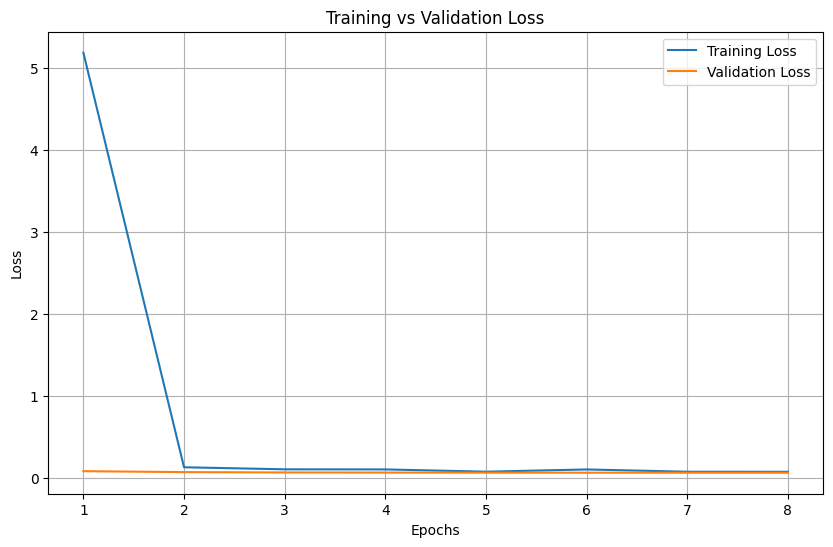

In [24]:
import matplotlib.pyplot as plt

def plot_training_loss(logs):
    # Ensure the length of both lists match for plotting
    train_loss = logs.get("train_loss", [])
    eval_loss = logs.get("eval_loss", [])
    
    # Truncate to the shorter length if they mismatch
    min_length = min(len(train_loss), len(eval_loss))
    train_loss = train_loss[:min_length]
    eval_loss = eval_loss[:min_length]
    epochs = list(range(1, min_length + 1))

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_loss, label="Training Loss")
    plt.plot(epochs, eval_loss, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

# ✅ Extract Training and Validation Loss from the Trainer
train_loss = [log["loss"] for log in trainer.state.log_history if "loss" in log]
eval_loss = [log["eval_loss"] for log in trainer.state.log_history if "eval_loss" in log]

# ✅ Call the function to plot
plot_training_loss({"train_loss": train_loss, "eval_loss": eval_loss})


### b) Bleu & Rouge Score

In [25]:
import evaluate
import torch
from transformers import AutoTokenizer, T5ForConditionalGeneration

# ✅ Load the tokenizer and metrics correctly
bleu = evaluate.load("sacrebleu")
rouge = evaluate.load("rouge")

# ✅ Load the fine-tuned model (Ensure the correct path to your fine-tuned model)
tokenizer = AutoTokenizer.from_pretrained("./fine_tuned_nanot5")  # ✅ Fine-Tuned Tokenizer
model = T5ForConditionalGeneration.from_pretrained("./fine_tuned_nanot5")  # ✅ Fine-Tuned Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ✅ Updated Evaluation Function for Fine-Tuned Model
def evaluate_bleu_rouge(model, test_dataset):
    model.eval()
    predictions = []
    references = []

    for example in test_dataset:
        # Proper handling of tensors using clone().detach()
        inputs = torch.tensor(example["input_ids"]).clone().detach().unsqueeze(0).to(model.device)
        outputs = model.generate(inputs, max_length=128)
        pred_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        ref_text = tokenizer.decode(example["labels"], skip_special_tokens=True)

        predictions.append(pred_text)
        references.append([ref_text])  # BLEU expects nested references

    # ✅ Compute BLEU and ROUGE Scores
    bleu_score = bleu.compute(predictions=predictions, references=references)
    rouge_score = rouge.compute(predictions=predictions, references=references)

    # ✅ Display Results
    print("\n✅ Evaluation Metrics:")
    print(f"BLEU Score: {bleu_score['score']:.2f}")
    print(f"ROUGE Score: {rouge_score}")

# ✅ Run the Evaluation on the Fine-Tuned Model
evaluate_bleu_rouge(model, test_dataset)


<ipython-input-25-dc69a6d64259>:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(example["input_ids"]).clone().detach().unsqueeze(0).to(model.device)



✅ Evaluation Metrics:
BLEU Score: 52.23
ROUGE Score: {'rouge1': 0.8018111892253702, 'rouge2': 0.6434300213819014, 'rougeL': 0.7859263061216786, 'rougeLsum': 0.7861348870744589}


### c) Prediction vs Reference Length Distribution

<ipython-input-26-833d087a805e>:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(example["input_ids"]).unsqueeze(0).to(model.device)


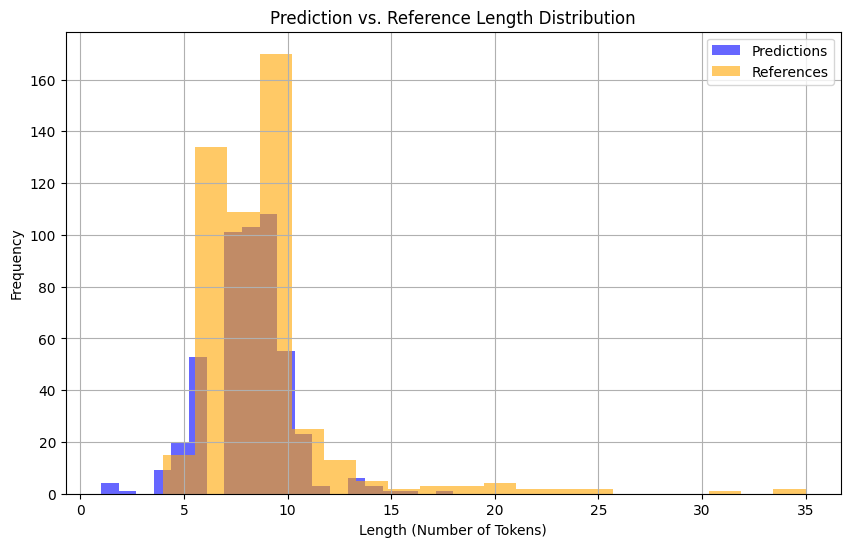

In [26]:
import matplotlib.pyplot as plt

tokenizer = AutoTokenizer.from_pretrained("./fine_tuned_nanot5")  # ✅ Fine-Tuned Tokenizer
model = T5ForConditionalGeneration.from_pretrained("./fine_tuned_nanot5")  # ✅ Fine-Tuned Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def plot_length_distribution(test_dataset, model, tokenizer):
    prediction_lengths = []
    reference_lengths = []

    for example in test_dataset:
        inputs = torch.tensor(example["input_ids"]).unsqueeze(0).to(model.device)
        outputs = model.generate(inputs, max_length=128)
        pred_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        ref_text = tokenizer.decode(example["labels"], skip_special_tokens=True)

        prediction_lengths.append(len(pred_text.split()))
        reference_lengths.append(len(ref_text.split()))

    # ✅ Plotting the Length Distributions
    plt.figure(figsize=(10, 6))
    plt.hist(prediction_lengths, bins=20, alpha=0.6, label="Predictions", color='blue')
    plt.hist(reference_lengths, bins=20, alpha=0.6, label="References", color='orange')
    plt.xlabel("Length (Number of Tokens)")
    plt.ylabel("Frequency")
    plt.title("Prediction vs. Reference Length Distribution")
    plt.legend()
    plt.grid(True)
    plt.show()

# ✅ Call the function
plot_length_distribution(test_dataset, model, tokenizer)


### d) BLEU and ROUGE Visualization

<ipython-input-27-3dd672ef9f8b>:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(example["input_ids"]).unsqueeze(0).to(model.device)


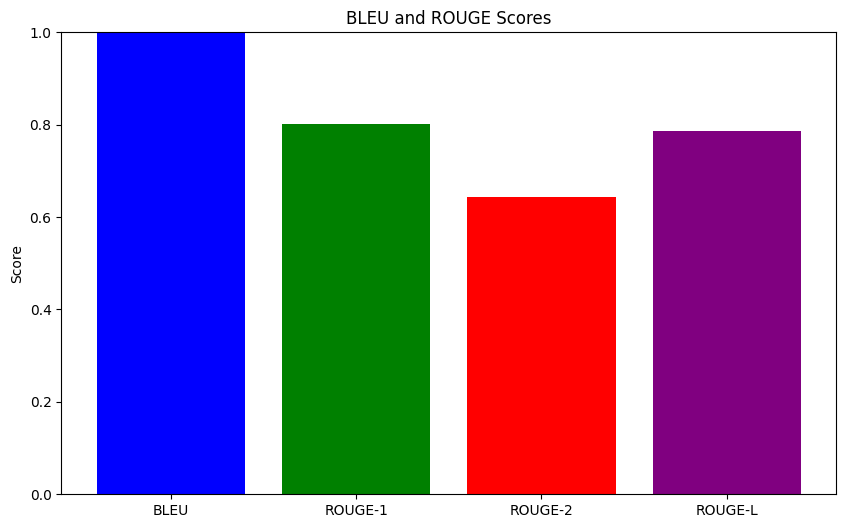


✅ BLEU Score: 52.23
ROUGE Scores: {'rouge1': 0.8018111892253702, 'rouge2': 0.6434300213819014, 'rougeL': 0.7859263061216786, 'rougeLsum': 0.7861348870744589}


In [27]:
tokenizer = AutoTokenizer.from_pretrained("./fine_tuned_nanot5")  # ✅ Fine-Tuned Tokenizer
model = T5ForConditionalGeneration.from_pretrained("./fine_tuned_nanot5")  # ✅ Fine-Tuned Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def visualize_bleu_rouge(model, test_dataset):
    predictions = []
    references = []

    for example in test_dataset:
        inputs = torch.tensor(example["input_ids"]).unsqueeze(0).to(model.device)
        outputs = model.generate(inputs, max_length=128)
        pred_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        ref_text = tokenizer.decode(example["labels"], skip_special_tokens=True)

        predictions.append(pred_text)
        references.append([ref_text])  # BLEU expects nested references

    # ✅ Compute BLEU and ROUGE Scores
    bleu_score = bleu.compute(predictions=predictions, references=references)
    rouge_score = rouge.compute(predictions=predictions, references=references)

    # ✅ Visualizing Results
    scores = [bleu_score['score'], rouge_score['rouge1'], rouge_score['rouge2'], rouge_score['rougeL']]
    metrics = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L"]

    plt.figure(figsize=(10, 6))
    plt.bar(metrics, scores, color=["blue", "green", "red", "purple"])
    plt.ylabel("Score")
    plt.title("BLEU and ROUGE Scores")
    plt.ylim(0, 1)
    plt.show()

    print(f"\n✅ BLEU Score: {bleu_score['score']:.2f}")
    print(f"ROUGE Scores: {rouge_score}")

# ✅ Call the Function for Evaluation
visualize_bleu_rouge(model, test_dataset)


## iIi. Evaluations Comparison (Base Model vs Fine-tuned Model)

<ipython-input-28-38dde1ab511b>:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(example["input_ids"]).clone().detach().unsqueeze(0).to(model.device)


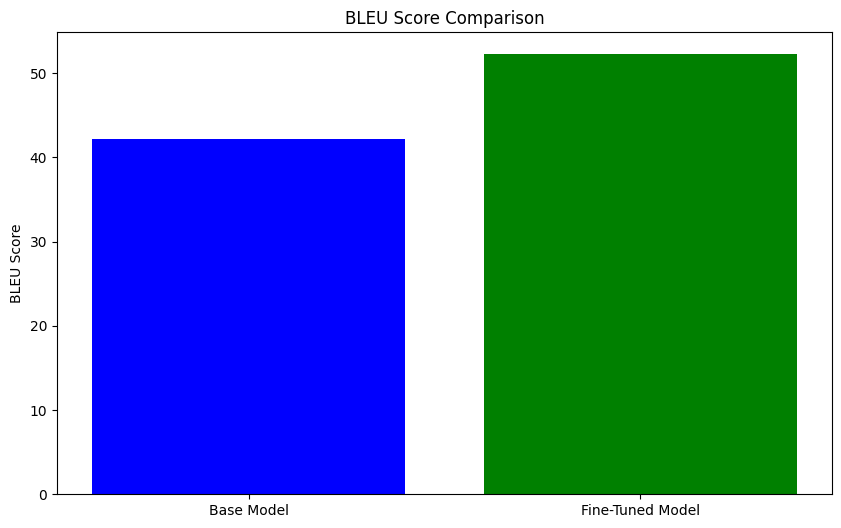

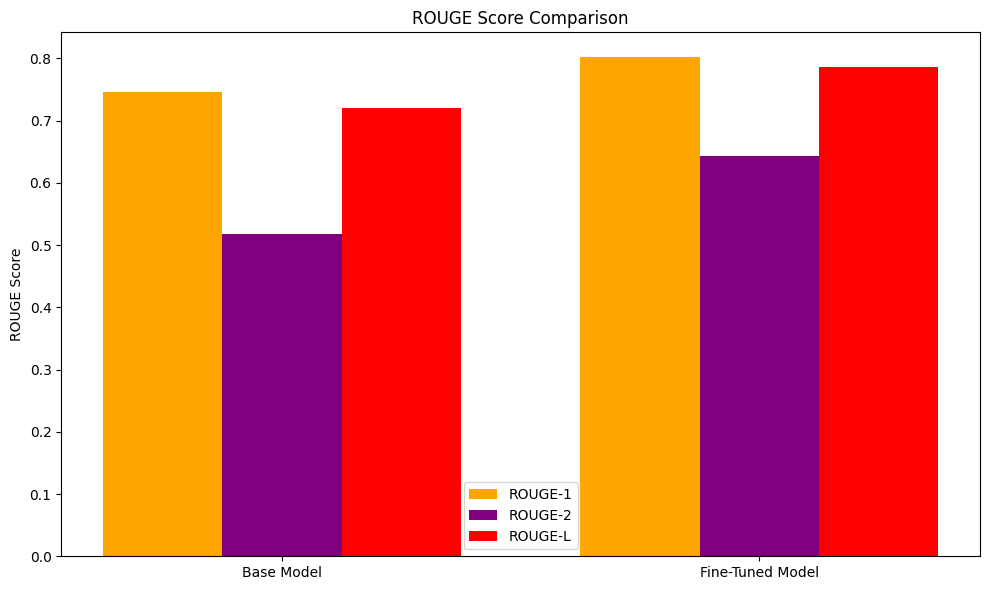

In [28]:
import evaluate
import torch
from transformers import AutoTokenizer, T5ForConditionalGeneration
import matplotlib.pyplot as plt

# ✅ Load the tokenizer and metrics correctly
bleu = evaluate.load("sacrebleu")
rouge = evaluate.load("rouge")

# ✅ Load the base and fine-tuned models
tokenizer = AutoTokenizer.from_pretrained('mesolitica/nanot5-small-malaysian-translation-v2')
base_model = T5ForConditionalGeneration.from_pretrained('mesolitica/nanot5-small-malaysian-translation-v2')
fine_tuned_model = T5ForConditionalGeneration.from_pretrained('./fine_tuned_nanot5')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_model.to(device)
fine_tuned_model.to(device)

# ✅ Updated Evaluation Function for BLEU and ROUGE
def evaluate_bleu_rouge(model, test_dataset):
    model.eval()
    predictions = []
    references = []

    for example in test_dataset:
        inputs = torch.tensor(example["input_ids"]).clone().detach().unsqueeze(0).to(model.device)
        outputs = model.generate(inputs, max_length=128)
        pred_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        ref_text = tokenizer.decode(example["labels"], skip_special_tokens=True)

        predictions.append(pred_text)
        references.append([ref_text])  # BLEU expects nested references

    # ✅ Compute BLEU and ROUGE Scores
    bleu_score = bleu.compute(predictions=predictions, references=references)["score"]
    rouge_score = rouge.compute(predictions=predictions, references=references)
    return bleu_score, rouge_score

# ✅ Assuming `test_dataset` is already tokenized and available
base_bleu, base_rouge = evaluate_bleu_rouge(base_model, test_dataset)
fine_tuned_bleu, fine_tuned_rouge = evaluate_bleu_rouge(fine_tuned_model, test_dataset)

# ✅ Prepare the data for visualization
models = ["Base Model", "Fine-Tuned Model"]
bleu_scores = [base_bleu, fine_tuned_bleu]
rouge_1 = [base_rouge['rouge1'], fine_tuned_rouge['rouge1']]
rouge_2 = [base_rouge['rouge2'], fine_tuned_rouge['rouge2']]
rouge_L = [base_rouge['rougeL'], fine_tuned_rouge['rougeL']]

# ✅ Plotting the BLEU score comparison
plt.figure(figsize=(10, 6))
plt.bar(models, bleu_scores, color=['blue', 'green'])
plt.title('BLEU Score Comparison')
plt.ylabel('BLEU Score')
plt.show()

# ✅ Plotting the ROUGE scores comparison
plt.figure(figsize=(10, 6))
bar_width = 0.25
index = range(len(models))

plt.bar(index, rouge_1, width=bar_width, label="ROUGE-1", color='orange')
plt.bar([i + bar_width for i in index], rouge_2, width=bar_width, label="ROUGE-2", color='purple')
plt.bar([i + 2 * bar_width for i in index], rouge_L, width=bar_width, label="ROUGE-L", color='red')

plt.title('ROUGE Score Comparison')
plt.ylabel('ROUGE Score')
plt.xticks([r + bar_width for r in range(len(models))], models)
plt.legend()
plt.tight_layout()
plt.show()



# 4. Downloading Model Zip

In [29]:
import shutil

# Create a zip archive of the fine-tuned model directory
shutil.make_archive("/kaggle/working/fine_tuned_nanot5", 'zip', "/kaggle/working/fine_tuned_nanot5")

print("✅ Model directory zipped successfully!")



✅ Model directory zipped successfully!
